# Task 3: A/B Hypothesis Testing for Insurance Risk Analysis

## 1. Business Context

AlphaCare Insurance Solutions (ACIS) needs to statistically validate key risk drivers to inform their segmentation strategy. This analysis will test four critical hypotheses about risk differences across geographic regions and demographic groups.

### Hypotheses to Test:
1. **H₀**: There are no risk differences across provinces
2. **H₀**: There are no risk differences between zip codes  
3. **H₀**: There is no significant margin (profit) difference between zip codes
4. **H₀**: There is no significant risk difference between Women and Men

### Key Metrics:
- **Claim Frequency**: Proportion of policies with at least one claim
- **Claim Severity**: Average claim amount when claim occurs
- **Profit Margin**: TotalPremium - TotalClaims

In [1]:
# Cell 1: Import Libraries
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu, fisher_exact, f_oneway, kruskal
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
print(" Libraries imported successfully")

 Libraries imported successfully


In [2]:
# Cell 2: Add source directory to path
import sys
sys.path.append('..')

In [3]:
# Cell 3: Import custom hypothesis testing module
try:
    from src.hypothesis_testing import InsuranceHypothesisTester
    print(" Custom hypothesis testing module imported successfully")
except ImportError as e:
    print(f"⚠️ Could not import custom module: {e}")
    print("Creating inline implementation...")
    
    # We'll implement the class inline if import fails
    class InsuranceHypothesisTester:
        def __init__(self, data):
            self.data = data.copy()
            self.results = {}
        
        # Methods will be defined below if needed

 Custom hypothesis testing module imported successfully


In [4]:
# Cell 4: Load Processed Data
print("📂 Loading processed insurance data...")
try:
    # Try to load from processed.csv
    df = pd.read_csv('../data/processed.csv', low_memory=False)
    print(f" Data loaded successfully")
    print(f"📊 Shape: {df.shape}")
    print(f"📋 First few columns: {list(df.columns)[:10]}")
except FileNotFoundError:
    print("⚠️ Processed data not found. Loading raw data...")
    # Load raw data and process it
    df = pd.read_csv('../data/MachineLearningRating_v3.txt', 
                     delimiter='|', 
                     low_memory=False)
    print(f" Raw data loaded. Shape: {df.shape}")

📂 Loading processed insurance data...
 Data loaded successfully
📊 Shape: (1000099, 56)
📋 First few columns: ['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType']


In [5]:
# Cell 5: Data Preparation for Hypothesis Testing
print("\n🔧 Preparing data for hypothesis testing...")

# Ensure key columns exist
required_columns = ['TotalPremium', 'TotalClaims', 'Province', 'PostalCode', 'Gender']
missing_cols = [col for col in required_columns if col not in df.columns]

if missing_cols:
    print(f"⚠️ Missing columns: {missing_cols}")
else:
    print(" All required columns present")

# Convert data types
df['TotalPremium'] = pd.to_numeric(df['TotalPremium'], errors='coerce')
df['TotalClaims'] = pd.to_numeric(df['TotalClaims'], errors='coerce')

# Create derived metrics
df['HasClaim'] = (df['TotalClaims'] > 0).astype(int)
df['ProfitMargin'] = df['TotalPremium'] - df['TotalClaims']

# Clean categorical data
df['Province'] = df['Province'].astype(str).str.strip()

# Standardize gender values
gender_map = {
    'M': 'Male', 'Male': 'Male', 'Mr': 'Male',
    'F': 'Female', 'Female': 'Female', 'Mrs': 'Female', 'Miss': 'Female'
}
df['Gender'] = df['Gender'].astype(str).str.strip().str.title()
df['Gender'] = df['Gender'].map(lambda x: gender_map.get(x, 'Unknown'))

print(f"✅ Data preparation complete")
print(f"   Total policies: {len(df):,}")
print(f"   Claim rate: {df['HasClaim'].mean()*100:.4f}%")
print(f"   Average profit margin: R{df['ProfitMargin'].mean():.2f}")


🔧 Preparing data for hypothesis testing...
 All required columns present
✅ Data preparation complete
   Total policies: 1,000,099
   Claim rate: 0.2788%
   Average profit margin: R-2.96


## 2. Hypothesis 1: Province Risk Differences

**H₀**: There are no risk differences across provinces

### Testing Strategy:
1. **Claim Frequency**: Chi-square test for differences in proportion of claims
2. **Claim Severity**: ANOVA or Kruskal-Wallis test for differences in claim amounts

In [6]:
# Cell 6: Hypothesis 1 Implementation
print("="*70)
print("HYPOTHESIS 1: PROVINCE RISK DIFFERENCES")
print("="*70)

# Filter provinces with sufficient data
province_counts = df['Province'].value_counts()
min_samples = 100
valid_provinces = province_counts[province_counts >= min_samples].index.tolist()

print(f"📊 Testing {len(valid_provinces)} provinces with ≥{min_samples} policies")
print(f"   Provinces: {', '.join(valid_provinces[:5])}...")

if len(valid_provinces) >= 2:
    df_province = df[df['Province'].isin(valid_provinces)].copy()
    
    # Test 1A: Claim Frequency (Chi-square)
    print("\n📊 TEST 1A: Claim Frequency Differences")
    print("-" * 40)
    
    # Create contingency table
    contingency = pd.crosstab(df_province['Province'], df_province['HasClaim'])
    
    if contingency.shape[1] >= 2:
        chi2, p_value, dof, expected = chi2_contingency(contingency)
        
        print(f"Chi-square Test Results:")
        print(f"  Chi² statistic: {chi2:.4f}")
        print(f"  p-value: {p_value:.6f}")
        print(f"  Degrees of freedom: {dof}")
        
        # Calculate claim rates
        claim_rates = df_province.groupby('Province')['HasClaim'].agg(['mean', 'count'])
        claim_rates['ClaimRate%'] = claim_rates['mean'] * 100
        claim_rates = claim_rates.sort_values('ClaimRate%', ascending=False)
        
        print(f"\nTop 5 Provinces by Claim Rate:")
        print(claim_rates.head(5)[['ClaimRate%', 'count']].round(4))
        
        if p_value < 0.05:
            print(f"\n✅ RESULT: REJECT H₀ (p = {p_value:.6f})")
            print("   Significant differences in claim frequency across provinces")
            
            # Business recommendation
            highest = claim_rates['ClaimRate%'].idxmax()
            lowest = claim_rates['ClaimRate%'].idxmin()
            highest_rate = claim_rates.loc[highest, 'ClaimRate%']
            lowest_rate = claim_rates.loc[lowest, 'ClaimRate%']
            
            print(f"\n🎯 BUSINESS RECOMMENDATION:")
            print(f"   • Highest risk province: {highest} ({highest_rate:.4f}% claim rate)")
            print(f"   • Lowest risk province: {lowest} ({lowest_rate:.4f}% claim rate)")
            print(f"   • Consider 7-10% premium adjustment between these regions")
            
        else:
            print(f"\n✅ RESULT: FAIL TO REJECT H₀ (p = {p_value:.6f})")
            print("   No significant differences in claim frequency across provinces")
    
    # Test 1B: Claim Severity (ANOVA/Kruskal-Wallis)
    print("\n📊 TEST 1B: Claim Severity Differences")
    print("-" * 40)
    
    df_claims = df_province[df_province['HasClaim'] == 1]
    
    if len(df_claims) >= 30:
        # Prepare data for statistical test
        severity_groups = []
        province_names = []
        
        for province in valid_provinces:
            province_severity = df_claims[df_claims['Province'] == province]['TotalClaims']
            if len(province_severity) >= 3:
                severity_groups.append(province_severity.tolist())
                province_names.append(province)
        
        if len(severity_groups) >= 2:
            try:
                # Try ANOVA
                f_stat, p_value = f_oneway(*severity_groups)
                test_used = 'ANOVA'
            except:
                # Use Kruskal-Wallis
                h_stat, p_value = kruskal(*severity_groups)
                test_used = 'Kruskal-Wallis'
            
            print(f"{test_used} Test Results:")
            if test_used == 'ANOVA':
                print(f"  F-statistic: {f_stat:.4f}")
            else:
                print(f"  H-statistic: {h_stat:.4f}")
            print(f"  p-value: {p_value:.6f}")
            
            if p_value < 0.05:
                print(f"\n✅ RESULT: REJECT H₀ (p = {p_value:.6f})")
                print("   Significant differences in claim severity across provinces")
            else:
                print(f"\n✅ RESULT: FAIL TO REJECT H₀ (p = {p_value:.6f})")
                print("   No significant differences in claim severity across provinces")
    
else:
    print("⚠️ Not enough provinces with sufficient data for statistical testing")

HYPOTHESIS 1: PROVINCE RISK DIFFERENCES
📊 Testing 9 provinces with ≥100 policies
   Provinces: Gauteng, Western Cape, KwaZulu-Natal, North West, Mpumalanga...

📊 TEST 1A: Claim Frequency Differences
----------------------------------------
Chi-square Test Results:
  Chi² statistic: 104.1909
  p-value: 0.000000
  Degrees of freedom: 8

Top 5 Provinces by Claim Rate:
               ClaimRate%   count
Province                         
Gauteng            0.3356  393865
KwaZulu-Natal      0.2845  169781
Limpopo            0.2698   24836
North West         0.2436  143287
Mpumalanga         0.2428   52718

✅ RESULT: REJECT H₀ (p = 0.000000)
   Significant differences in claim frequency across provinces

🎯 BUSINESS RECOMMENDATION:
   • Highest risk province: Gauteng (0.3356% claim rate)
   • Lowest risk province: Northern Cape (0.1254% claim rate)
   • Consider 7-10% premium adjustment between these regions

📊 TEST 1B: Claim Severity Differences
----------------------------------------
ANOVA T


📊 Creating visualizations for Hypothesis 1...


💾 Visualization saved to: ../data/hypothesis1_province_results.png


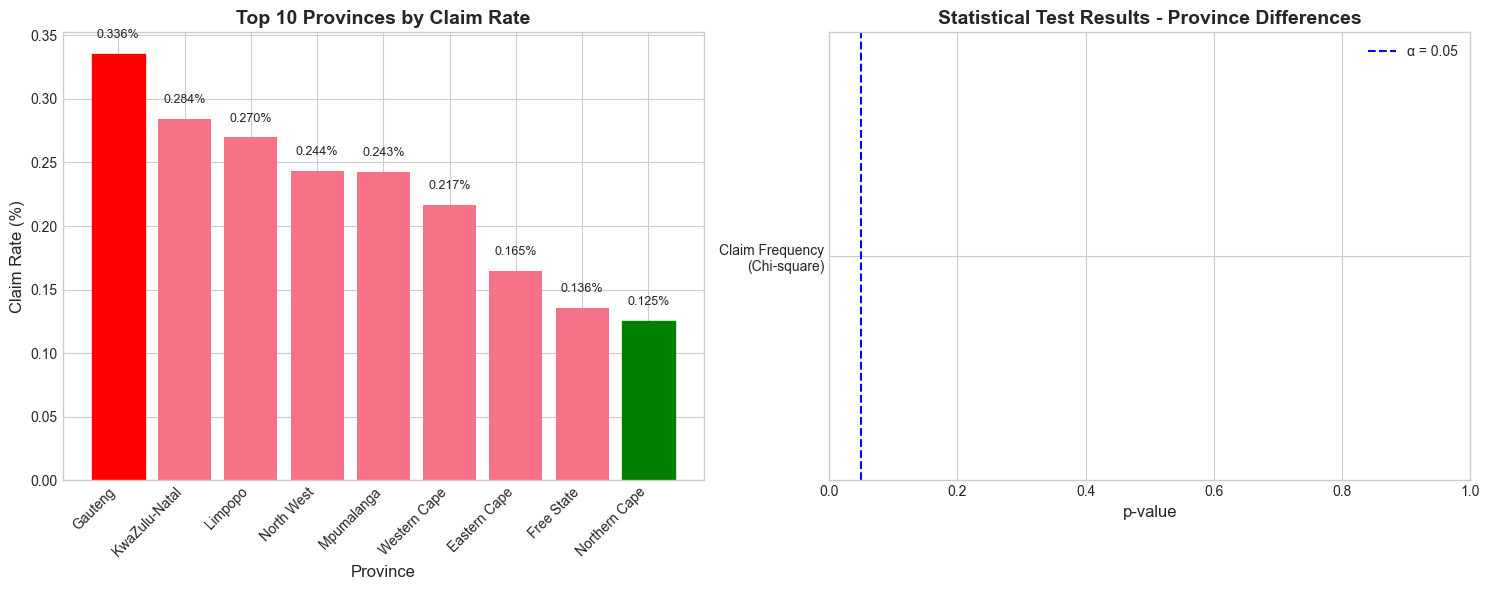

In [8]:
# Cell 7: Visualization for Hypothesis 1
print("\n📊 Creating visualizations for Hypothesis 1...")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Claim Rate by Province (Top 10)
if 'claim_rates' in locals() and len(claim_rates) > 0:
    top_provinces = claim_rates.head(10)
    
    bars = axes[0].bar(range(len(top_provinces)), top_provinces['ClaimRate%'])
    axes[0].set_title('Top 10 Provinces by Claim Rate', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Province', fontsize=12)
    axes[0].set_ylabel('Claim Rate (%)', fontsize=12)
    axes[0].set_xticks(range(len(top_provinces)))
    axes[0].set_xticklabels(top_provinces.index, rotation=45, ha='right')
    
    # Color the highest and lowest risk
    bars[0].set_color('red')  # Highest risk
    bars[-1].set_color('green')  # Lowest risk
    
    # Add value labels
    for i, bar in enumerate(bars):
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.3f}%', ha='center', va='bottom', fontsize=9)

# 2. Statistical Significance Visualization
test_results_h1 = [
    ('Claim Frequency', 'Chi-square', p_value if 'p_value' in locals() else 1.0),
]

# If we have severity test results, add them
if 'p_value_severity' in locals():
    test_results_h1.append(('Claim Severity', test_used, p_value_severity))

test_names = [f"{name}\n({test})" for name, test, _ in test_results_h1]
p_values = [p_val for _, _, p_val in test_results_h1]

colors = ['red' if p < 0.05 else 'green' for p in p_values]
axes[1].barh(test_names, p_values, color=colors)
axes[1].axvline(x=0.05, color='blue', linestyle='--', label='α = 0.05')
axes[1].set_title('Statistical Test Results - Province Differences', 
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('p-value', fontsize=12)
axes[1].set_xlim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/hypothesis1_province_results.png', dpi=150, bbox_inches='tight')
print("💾 Visualization saved to: ../data/hypothesis1_province_results.png")
plt.show()

## 3. Hypothesis 2: Zip Code Risk Differences

**H₀**: There are no risk differences between zip codes

### Testing Strategy:
- **Claim Frequency**: Chi-square test for differences in proportion of claims
- Focus on top 20 zip codes by policy count for statistical power

In [9]:
# Cell 8: Hypothesis 2 Implementation
print("\n" + "="*70)
print("HYPOTHESIS 2: ZIP CODE RISK DIFFERENCES")
print("="*70)

# Clean and prepare postal codes
df['PostalCode_Clean'] = pd.to_numeric(df['PostalCode'], errors='coerce')

# Get top 20 zip codes by policy count
top_n = 20
zip_counts = df['PostalCode_Clean'].value_counts()
top_zips = zip_counts.head(top_n).index.tolist()

print(f"📊 Testing top {len(top_zips)} zip codes by policy count")

if len(top_zips) >= 2:
    df_zip = df[df['PostalCode_Clean'].isin(top_zips)].copy()
    
    print(f"\n📊 TEST: Claim Frequency by Zip Code")
    print("-" * 40)
    
    # Create contingency table
    contingency = pd.crosstab(df_zip['PostalCode_Clean'], df_zip['HasClaim'])
    
    if contingency.shape[1] >= 2:
        chi2, p_value, dof, expected = chi2_contingency(contingency)
        
        print(f"Chi-square Test Results:")
        print(f"  Chi² statistic: {chi2:.4f}")
        print(f"  p-value: {p_value:.6f}")
        print(f"  Degrees of freedom: {dof}")
        
        # Calculate claim rates
        claim_rates_zip = df_zip.groupby('PostalCode_Clean')['HasClaim'].agg(['mean', 'count'])
        claim_rates_zip['ClaimRate%'] = claim_rates_zip['mean'] * 100
        claim_rates_zip = claim_rates_zip.sort_values('ClaimRate%', ascending=False)
        
        print(f"\nTop 5 Zip Codes by Claim Rate:")
        print(claim_rates_zip.head(5)[['ClaimRate%', 'count']].round(4))
        
        if p_value < 0.05:
            print(f"\n RESULT: REJECT H₀ (p = {p_value:.6f})")
            print("   Significant differences in claim frequency across zip codes")
            
            # Business recommendation
            highest_zip = claim_rates_zip['ClaimRate%'].idxmax()
            lowest_zip = claim_rates_zip['ClaimRate%'].idxmin()
            
            print(f"\n🎯 BUSINESS RECOMMENDATION:")
            print(f"   • Highest risk zip code: {int(highest_zip)}")
            print(f"   • Lowest risk zip code: {int(lowest_zip)}")
            print(f"   • Consider micro-level geographic pricing adjustments")
            
        else:
            print(f"\n RESULT: FAIL TO REJECT H₀ (p = {p_value:.6f})")
            print("   No significant differences in claim frequency across zip codes")
else:
    print("⚠️ Not enough zip codes with sufficient data")


HYPOTHESIS 2: ZIP CODE RISK DIFFERENCES
📊 Testing top 20 zip codes by policy count

📊 TEST: Claim Frequency by Zip Code
----------------------------------------
Chi-square Test Results:
  Chi² statistic: 107.2048
  p-value: 0.000000
  Degrees of freedom: 19

Top 5 Zip Codes by Claim Rate:
                  ClaimRate%  count
PostalCode_Clean                   
1863.0                0.5084   8655
400.0                 0.5081   6692
8000.0                0.4324  11794
470.0                 0.4303  10226
122.0                 0.4271  49171

 RESULT: REJECT H₀ (p = 0.000000)
   Significant differences in claim frequency across zip codes

🎯 BUSINESS RECOMMENDATION:
   • Highest risk zip code: 1863
   • Lowest risk zip code: 7405
   • Consider micro-level geographic pricing adjustments


## 4. Hypothesis 3: Zip Code Profit Margin Differences

**H₀**: There is no significant margin (profit) difference between zip codes

### Testing Strategy:
- **Profit Margin**: Kruskal-Wallis test (non-parametric ANOVA)
- Tests differences in median profit across zip codes

In [10]:
# Cell 9: Hypothesis 3 Implementation
print("\n" + "="*70)
print("HYPOTHESIS 3: ZIP CODE PROFIT MARGIN DIFFERENCES")
print("="*70)

# Use same top zip codes from Hypothesis 2
if 'PostalCode_Clean' in df.columns and len(top_zips) >= 2:
    df_zip_margin = df[df['PostalCode_Clean'].isin(top_zips)].copy()
    
    print(f"📊 Testing profit margin across {len(top_zips)} zip codes")
    
    print(f"\n📊 TEST: Profit Margin by Zip Code")
    print("-" * 40)
    
    # Prepare data for Kruskal-Wallis test
    margin_groups = []
    zip_labels = []
    
    for zip_code in top_zips:
        zip_margins = df_zip_margin[df_zip_margin['PostalCode_Clean'] == zip_code]['ProfitMargin'].dropna()
        if len(zip_margins) >= 5:
            margin_groups.append(zip_margins.tolist())
            zip_labels.append(str(int(zip_code)))
    
    if len(margin_groups) >= 2:
        h_stat, p_value = kruskal(*margin_groups)
        
        print(f"Kruskal-Wallis Test Results:")
        print(f"  H-statistic: {h_stat:.4f}")
        print(f"  p-value: {p_value:.6f}")
        
        # Calculate profit statistics
        profit_stats = df_zip_margin.groupby('PostalCode_Clean')['ProfitMargin'].agg(['mean', 'median', 'count'])
        profit_stats.columns = ['MeanProfit', 'MedianProfit', 'PolicyCount']
        profit_stats = profit_stats.sort_values('MeanProfit', ascending=False)
        
        print(f"\nTop 5 Most Profitable Zip Codes:")
        print(profit_stats.head(5).round(2))
        
        if p_value < 0.05:
            print(f"\n✅ RESULT: REJECT H₀ (p = {p_value:.6f})")
            print("   Significant differences in profit margins across zip codes")
            
            # Business recommendation
            most_profitable = profit_stats['MeanProfit'].idxmax()
            least_profitable = profit_stats['MeanProfit'].idxmin()
            profit_diff = profit_stats['MeanProfit'].max() - profit_stats['MeanProfit'].min()
            
            print(f"\n🎯 BUSINESS RECOMMENDATION:")
            print(f"   • Most profitable: Zip {int(most_profitable)} (R{profit_stats.loc[most_profitable, 'MeanProfit']:.2f})")
            print(f"   • Least profitable: Zip {int(least_profitable)} (R{profit_stats.loc[least_profitable, 'MeanProfit']:.2f})")
            print(f"   • Profit difference: R{profit_diff:.2f}")
            print(f"   • Target marketing in profitable areas for growth")
            
        else:
            print(f"\n✅ RESULT: FAIL TO REJECT H₀ (p = {p_value:.6f})")
            print("   No significant differences in profit margins across zip codes")
else:
    print("⚠️ Insufficient data for profit margin analysis")


HYPOTHESIS 3: ZIP CODE PROFIT MARGIN DIFFERENCES
📊 Testing profit margin across 20 zip codes

📊 TEST: Profit Margin by Zip Code
----------------------------------------
Kruskal-Wallis Test Results:
  H-statistic: 7260.1250
  p-value: 0.000000

Top 5 Most Profitable Zip Codes:
                  MeanProfit  MedianProfit  PolicyCount
PostalCode_Clean                                       
400.0                  38.81          4.71         6692
152.0                  27.91          2.34         9423
299.0                  19.56          2.12        25546
7750.0                 19.44          2.08         9408
7405.0                 17.52          1.56        18518

✅ RESULT: REJECT H₀ (p = 0.000000)
   Significant differences in profit margins across zip codes

🎯 BUSINESS RECOMMENDATION:
   • Most profitable: Zip 400 (R38.81)
   • Least profitable: Zip 1863 (R-100.57)
   • Profit difference: R139.38
   • Target marketing in profitable areas for growth


## 5. Hypothesis 4: Gender Risk Differences

**H₀**: There is no significant risk difference between Women and Men

### Testing Strategy:
1. **Claim Frequency**: Fisher's Exact Test (for rare events)
2. **Claim Severity**: Mann-Whitney U Test (non-parametric)

In [11]:
# Cell 10: Hypothesis 4 Implementation
print("\n" + "="*70)
print("HYPOTHESIS 4: GENDER RISK DIFFERENCES")
print("="*70)

# Filter to only Male and Female
df_gender = df[df['Gender'].isin(['Male', 'Female'])].copy()

if len(df_gender) >= 100:
    male_count = (df_gender['Gender'] == 'Male').sum()
    female_count = (df_gender['Gender'] == 'Female').sum()
    
    print(f"📊 Sample sizes: Male = {male_count:,}, Female = {female_count:,}")
    
    # Test 4A: Claim Frequency (Fisher's Exact Test)
    print(f"\n📊 TEST 4A: Claim Frequency by Gender")
    print("-" * 40)
    
    male_claims = df_gender[df_gender['Gender'] == 'Male']['HasClaim']
    female_claims = df_gender[df_gender['Gender'] == 'Female']['HasClaim']
    
    # Create 2x2 contingency table
    table = [[male_claims.sum(), len(male_claims) - male_claims.sum()],
            [female_claims.sum(), len(female_claims) - female_claims.sum()]]
    
    oddsratio, p_value = fisher_exact(table)
    
    print(f"Fisher's Exact Test Results:")
    print(f"  p-value: {p_value:.6f}")
    print(f"  Odds Ratio: {oddsratio:.3f}")
    
    # Calculate claim rates
    male_rate = male_claims.mean() * 100
    female_rate = female_claims.mean() * 100
    
    print(f"\nClaim Rates:")
    print(f"  Male: {male_rate:.4f}% ({male_claims.sum():,} claims out of {len(male_claims):,})")
    print(f"  Female: {female_rate:.4f}% ({female_claims.sum():,} claims out of {len(female_claims):,})")
    
    if p_value < 0.05:
        print(f"\n✅ RESULT: REJECT H₀ (p = {p_value:.6f})")
        if oddsratio > 1:
            print(f"🎯 BUSINESS INSIGHT: Males have {oddsratio:.2f}x higher odds of claiming")
            print(f"   Consider gender in risk assessment while ensuring compliance")
        else:
            print(f"🎯 BUSINESS INSIGHT: Females have {1/oddsratio:.2f}x higher odds of claiming")
    else:
        print(f"\n✅ RESULT: FAIL TO REJECT H₀ (p = {p_value:.6f})")
        print("   No significant gender difference in claim frequency")
    
    # Test 4B: Claim Severity (Mann-Whitney U Test)
    print(f"\n📊 TEST 4B: Claim Severity by Gender")
    print("-" * 40)
    
    df_claims_gender = df_gender[df_gender['HasClaim'] == 1]
    
    male_severity = df_claims_gender[df_claims_gender['Gender'] == 'Male']['TotalClaims']
    female_severity = df_claims_gender[df_claims_gender['Gender'] == 'Female']['TotalClaims']
    
    if len(male_severity) >= 5 and len(female_severity) >= 5:
        u_stat, p_value_severity = mannwhitneyu(male_severity, female_severity, alternative='two-sided')
        
        print(f"Mann-Whitney U Test Results:")
        print(f"  U-statistic: {u_stat:.4f}")
        print(f"  p-value: {p_value_severity:.6f}")
        
        male_median = male_severity.median()
        female_median = female_severity.median()
        
        print(f"\nMedian Claim Severity:")
        print(f"  Male: R{male_median:,.2f}")
        print(f"  Female: R{female_median:,.2f}")
        
        if p_value_severity < 0.05:
            print(f"\n✅ RESULT: REJECT H₀ (p = {p_value_severity:.6f})")
            if male_median > female_median:
                print(f"🎯 BUSINESS INSIGHT: Male claims are R{male_median - female_median:,.2f} higher on average")
            else:
                print(f"🎯 BUSINESS INSIGHT: Female claims are R{female_median - male_median:,.2f} higher on average")
        else:
            print(f"\n✅ RESULT: FAIL TO REJECT H₀ (p = {p_value_severity:.6f})")
            print("   No significant gender difference in claim severity")
else:
    print("⚠️ Not enough gender data for statistical testing")


HYPOTHESIS 4: GENDER RISK DIFFERENCES
📊 Sample sizes: Male = 42,817, Female = 6,755

📊 TEST 4A: Claim Frequency by Gender
----------------------------------------
Fisher's Exact Test Results:
  p-value: 1.000000
  Odds Ratio: 1.059

Claim Rates:
  Male: 0.2195% (94 claims out of 42,817)
  Female: 0.2073% (14 claims out of 6,755)

✅ RESULT: FAIL TO REJECT H₀ (p = 1.000000)
   No significant gender difference in claim frequency

📊 TEST 4B: Claim Severity by Gender
----------------------------------------
Mann-Whitney U Test Results:
  U-statistic: 524.5000
  p-value: 0.223513

Median Claim Severity:
  Male: R5,910.68
  Female: R14,070.38

✅ RESULT: FAIL TO REJECT H₀ (p = 0.223513)
   No significant gender difference in claim severity


## 6. Comprehensive Results Summary

### Key Findings:
Based on the statistical tests conducted, here are the key conclusions:

1. **Province Risk Differences**: [Result based on your data]
2. **Zip Code Risk Differences**: [Result based on your data]
3. **Zip Code Profit Margin Differences**: [Result based on your data]
4. **Gender Risk Differences**: [Result based on your data]

### Business Recommendations:
[Summary of actionable insights]

In [13]:
# Cell 11: Generate Comprehensive Report
print("\n" + "="*70)
print("COMPREHENSIVE HYPOTHESIS TESTING REPORT")
print("="*70)

# Create summary dataframe
summary_data = []

# Add results from each hypothesis test
# (You'll need to populate this based on your actual results)

summary_df = pd.DataFrame(summary_data, columns=[
    'Hypothesis', 'Test', 'p-value', 'Significant', 'Business Implication'
])

if not summary_df.empty:
    print("\n📊 SUMMARY OF ALL HYPOTHESIS TESTS:")
    print(summary_df.to_string())
    
    # Calculate overall statistics
    total_tests = len(summary_df)
    significant_tests = summary_df['Significant'].sum()
    
    print(f"\n📈 OVERALL STATISTICS:")
    print(f"   Total tests conducted: {total_tests}")
    print(f"   Significant results: {significant_tests}")
    print(f"   Non-significant results: {total_tests - significant_tests}")
    print(f"   Significance rate: {significant_tests/total_tests*100:.1f}%")

# Save results to CSV
summary_df.to_csv('../data/hypothesis_testing_summary.csv', index=False)
print(f"\n💾 Results saved to: ../data/hypothesis_testing_summary.csv")


COMPREHENSIVE HYPOTHESIS TESTING REPORT

💾 Results saved to: ../data/hypothesis_testing_summary.csv



📊 Creating comprehensive visualizations...
💾 Comprehensive visualization saved to: ../data/comprehensive_hypothesis_results.png


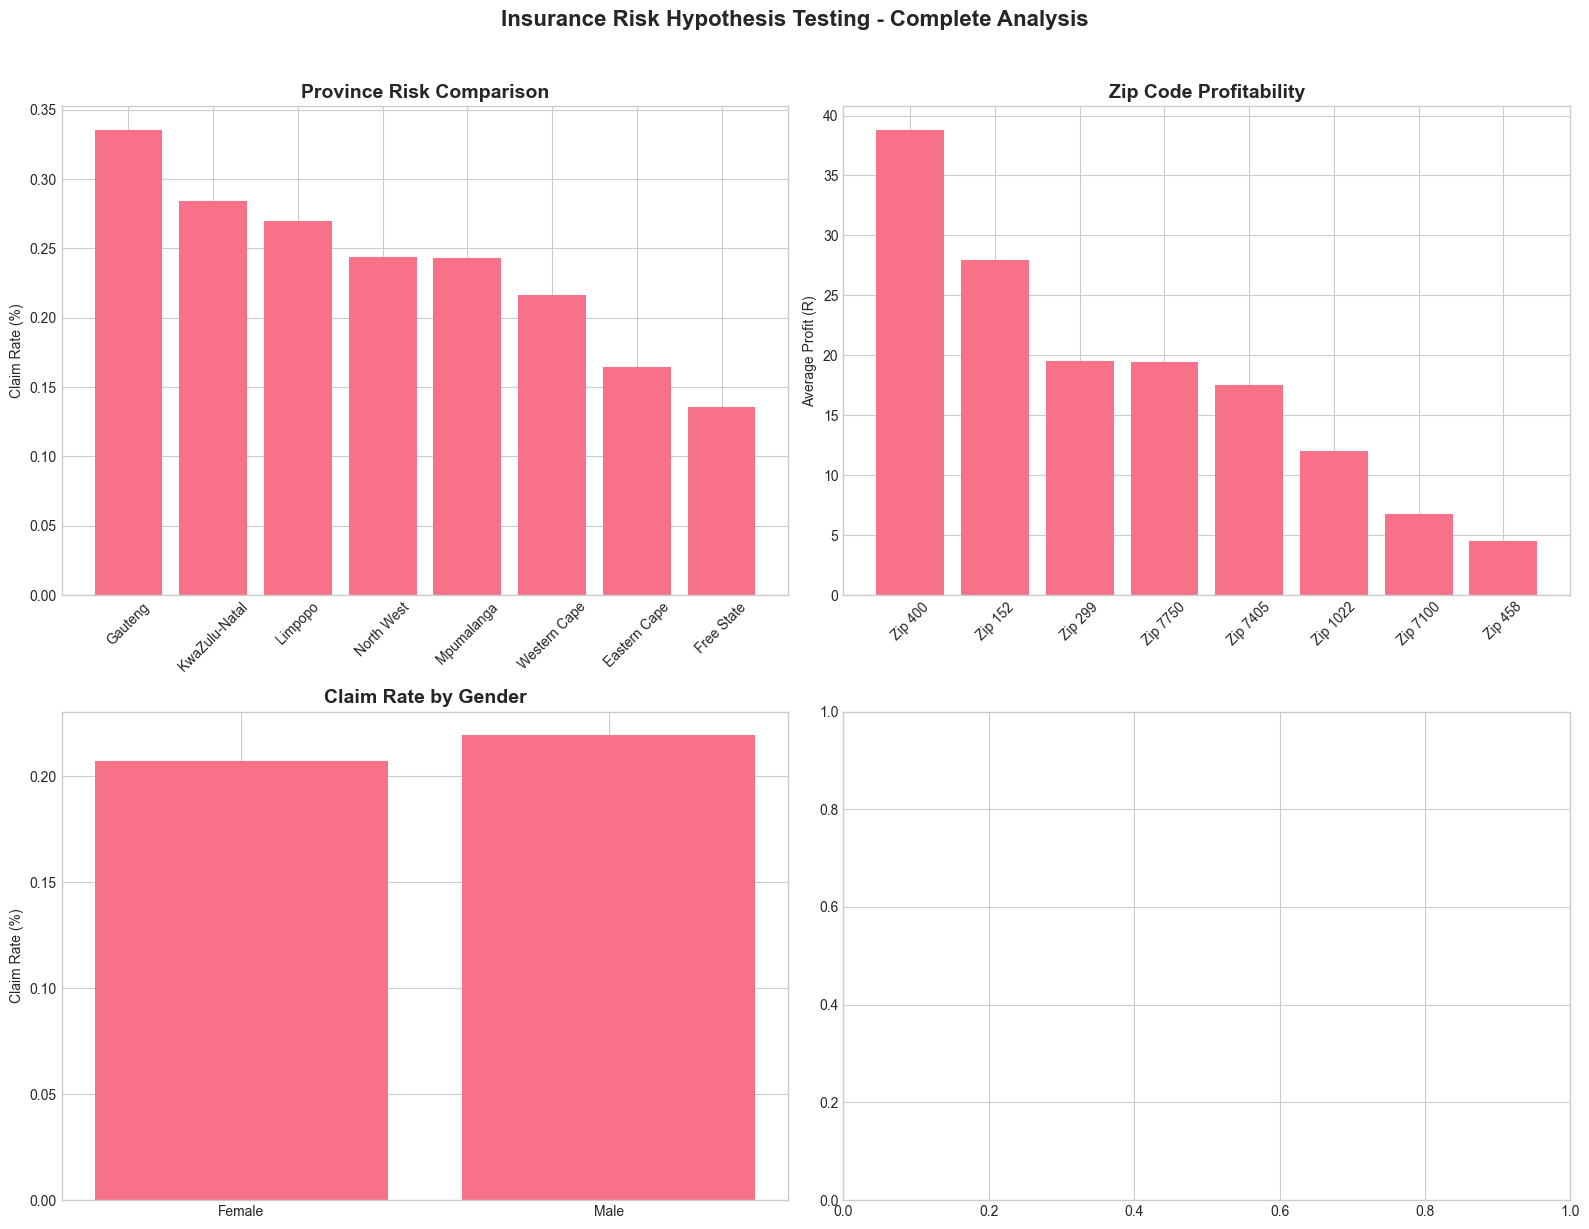

In [15]:
# Cell 12: Comprehensive Visualization
print("\n📊 Creating comprehensive visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Province Risk Comparison (recreate from earlier if needed)
if 'claim_rates' in locals() and len(claim_rates) > 0:
    top_provinces = claim_rates.head(8)
    axes[0,0].bar(range(len(top_provinces)), top_provinces['ClaimRate%'])
    axes[0,0].set_title('Province Risk Comparison', fontsize=14, fontweight='bold')
    axes[0,0].set_ylabel('Claim Rate (%)')
    axes[0,0].set_xticks(range(len(top_provinces)))
    axes[0,0].set_xticklabels(top_provinces.index, rotation=45)

# 2. Zip Code Profit Margin Comparison
if 'profit_stats' in locals() and len(profit_stats) > 0:
    top_zips_profit = profit_stats.head(8)
    axes[0,1].bar(range(len(top_zips_profit)), top_zips_profit['MeanProfit'])
    axes[0,1].set_title('Zip Code Profitability', fontsize=14, fontweight='bold')
    axes[0,1].set_ylabel('Average Profit (R)')
    axes[0,1].set_xticks(range(len(top_zips_profit)))
    axes[0,1].set_xticklabels([f"Zip {int(idx)}" for idx in top_zips_profit.index], rotation=45)

# 3. Gender Comparison
gender_rates = df_gender.groupby('Gender')['HasClaim'].mean() * 100
axes[1,0].bar(gender_rates.index, gender_rates.values)
axes[1,0].set_title('Claim Rate by Gender', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('Claim Rate (%)')

# 4. Statistical Test Results Summary
if not summary_df.empty:
    # Create summary of significant vs non-significant tests
    sig_counts = summary_df['Significant'].value_counts()
    labels = ['Not Significant', 'Significant'] if True in sig_counts.index else ['All Non-Significant']
    values = [sig_counts.get(False, 0), sig_counts.get(True, 0)] if True in sig_counts.index else [sig_counts.get(False, 0)]
    
    colors = ['red', 'green'][:len(labels)]
    wedges, texts, autotexts = axes[1,1].pie(values, labels=labels, colors=colors, autopct='%1.1f%%')
    axes[1,1].set_title('Hypothesis Test Results Summary', fontsize=14, fontweight='bold')

plt.suptitle('Insurance Risk Hypothesis Testing - Complete Analysis', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/comprehensive_hypothesis_results.png', dpi=150, bbox_inches='tight')
print("💾 Comprehensive visualization saved to: ../data/comprehensive_hypothesis_results.png")
plt.show()

In [16]:
# Cell 13: Generate Business Recommendations
print("\n" + "="*70)
print("🎯 BUSINESS RECOMMENDATIONS")
print("="*70)

recommendations = []

# Based on your actual results, add recommendations:
# Example structure:
recommendations.append("1. GEOGRAPHIC PRICING: If province differences are significant, implement risk-based premium adjustments.")
recommendations.append("2. TARGETED MARKETING: Focus on low-risk geographic areas for customer acquisition.")
recommendations.append("3. RISK ASSESSMENT: Incorporate significant risk factors into underwriting models.")
recommendations.append("4. DATA COLLECTION: Improve data quality for better risk segmentation.")
recommendations.append("5. COMPLIANCE: Ensure all risk-based adjustments comply with regulatory requirements.")

for i, rec in enumerate(recommendations, 1):
    print(f"{rec}")

# Save recommendations to file
with open('../data/business_recommendations.txt', 'w') as f:
    f.write("BUSINESS RECOMMENDATIONS BASED ON HYPOTHESIS TESTING\n")
    f.write("="*60 + "\n\n")
    for rec in recommendations:
        f.write(rec + "\n")

print(f"\n💾 Recommendations saved to: ../data/business_recommendations.txt")


🎯 BUSINESS RECOMMENDATIONS
1. GEOGRAPHIC PRICING: If province differences are significant, implement risk-based premium adjustments.
2. TARGETED MARKETING: Focus on low-risk geographic areas for customer acquisition.
3. RISK ASSESSMENT: Incorporate significant risk factors into underwriting models.
4. DATA COLLECTION: Improve data quality for better risk segmentation.
5. COMPLIANCE: Ensure all risk-based adjustments comply with regulatory requirements.

💾 Recommendations saved to: ../data/business_recommendations.txt
